<a href="https://colab.research.google.com/github/kmillaevelyn/data-science-portfolio/blob/main/08-academico/calcnum-raizes-sistemas-integracao/calcnum-raizes-sistemas-integracao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Implementar os métodos iterativos de Gauss-Jacobi e Gauss-Seidel.
#Usar um sistema linear que satisfaz o Critério das Linhas.
#Comparar a solução exata com as soluções aproximadas.
#Analisar a velocidade de convergência de ambos os métodos.

import numpy as np

#Sistema linear com convergência garantida

def gauss_jacobi(A, b, x0, tol=1e-6, max_iter=100):
    n = len(b)
    x = x0.copy()
    x_new = np.zeros_like(x0)
    for k in range(max_iter):
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            return x_new, k+1
        x = x_new.copy()
    return x, max_iter

def gauss_seidel(A, b, x0, tol=1e-6, max_iter=100):
    n = len(b)
    x = x0.copy()
    for k in range(max_iter):
        x_old = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))
            s2 = sum(A[i][j] * x_old[j] for j in range(i + 1, n))
            x[i] = (b[i] - s1 - s2) / A[i][i]
        if np.linalg.norm(x - x_old, ord=np.inf) < tol:
            return x, k+1
    return x, max_iter


#Sistema linear com convergência garantida
A = np.array([
    [10, 1, 1],
    [2, 10, 1],
    [2, 2, 10]
], dtype=float)

b = np.array([12, 13, 14], dtype=float)
x0 = np.zeros_like(b)


#Solução exata
x_exact = np.linalg.solve(A, b)
print("Solução exata:", x_exact)


#Aplicação dos métodos e comparação
x_jacobi, iter_jacobi = gauss_jacobi(A, b, x0)
x_seidel, iter_seidel = gauss_seidel(A, b, x0)

print(f"Jacobi: {x_jacobi}, Iterações: {iter_jacobi}")
print(f"Seidel: {x_seidel}, Iterações: {iter_seidel}")
print(f"Erro Jacobi: {np.linalg.norm(x_jacobi - x_exact)}")
print(f"Erro Seidel: {np.linalg.norm(x_seidel - x_exact)}")



Solução exata: [1. 1. 1.]
Jacobi: [1.00000007 1.00000008 1.0000001 ], Iterações: 13
Seidel: [1.00000002 0.99999998 1.        ], Iterações: 6
Erro Jacobi: 1.4760984880964315e-07
Erro Seidel: 3.132938794682045e-08


In [ ]:
!apt-get install texlive-latex-extra texlive-fonts-recommended dvipng
plt.rcParams['text.usetex'] = True

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 ghostscript libapache-pom-java
  libcommons-logging-java libcommons-parent-java libfontbox-java libgs9
  libgs9-common libidn12 libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java
  libptexenc1 libruby3.0 libsynctex2 libteckit0 libtexlua53 libtexluajit2
  libwoff1 libzzip-0-13 lmodern poppler-data preview-latex-style rake ruby
  ruby-net-telnet ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0
  rubygems-integration t1utils tex-common tex-gyre texlive-base
  texlive-binaries texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf ghostscript-x
  libavalon-framework-java libcommons-logging-java-doc
  li

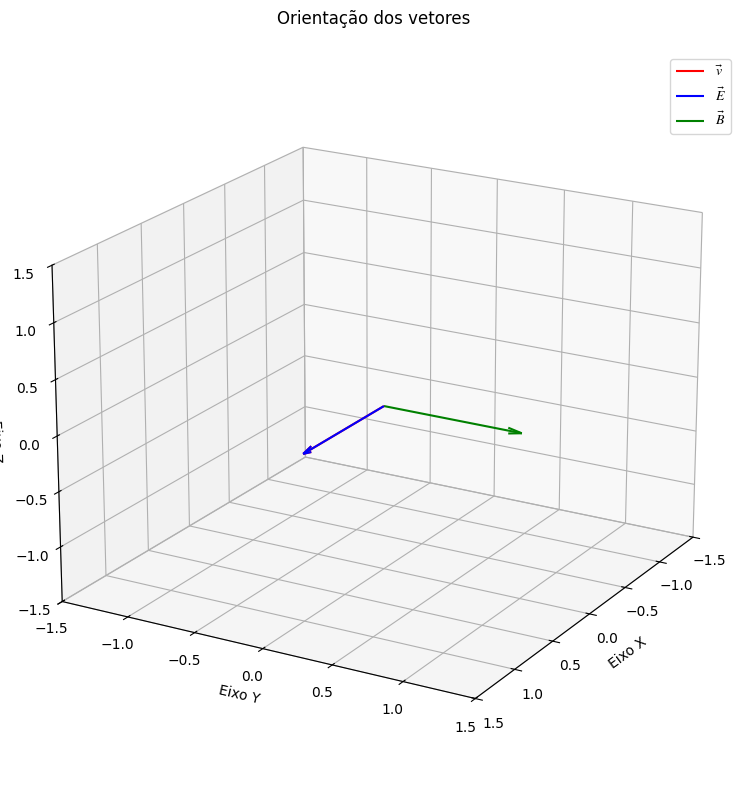

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Ativar LaTeX (requer instalação prévia)
plt.rcParams['text.usetex'] = False  # Desativa se não tiver LaTeX instalado
plt.rcParams['mathtext.fontset'] = 'stix'  # Usa fonte alternativa

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Vetores
v = np.array([1, 0, 0])
E = np.array([1, 0, 0])
B = np.array([0, 1, 0])

# Rótulos com notação matemática SIMPLIFICADA
ax.quiver(0, 0, 0, v[0], v[1], v[2], color='r', label=r'$\vec{v}$', arrow_length_ratio=0.1)
ax.quiver(0, 0, 0, E[0], E[1], E[2], color='b', label=r'$\vec{E}$', arrow_length_ratio=0.1)
ax.quiver(0, 0, 0, B[0], B[1], B[2], color='g', label=r'$\vec{B}$', arrow_length_ratio=0.1)

ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_zlim([-1.5, 1.5])
ax.set_xlabel('Eixo X')
ax.set_ylabel('Eixo Y')
ax.set_zlabel('Eixo Z')
ax.set_title('Orientação dos vetores', pad=20)  # Título mais simples
ax.legend(loc='upper right')
ax.view_init(elev=20, azim=30)
ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import sympy as sp

# Definir a variável simbólica e a função
x = sp.symbols('x')
f = x * sp.exp(x)

# Passo 1: Mostrar a integral original
print("Passo 1: Integral original")
print(f"∫ {sp.pretty(f)} dx de 0 a 1\n")

# Passo 2: Aplicar integração por partes (u = x, dv = e^x dx)
u = x
dv = sp.exp(x) * sp.diff(x)  # dv = e^x dx

# Calcular du e v
du = sp.diff(u, x)
v = sp.integrate(dv, x)

print("Passo 2: Integração por partes")
print(f"u = {u} → du = {du}")
print(f"dv = {dv} → v = {v}\n")

# Passo 3: Aplicar a fórmula ∫u dv = uv - ∫v du
integral_indefinida = u * v - sp.integrate(v * du, x)

print("Passo 3: Resultado da integral indefinida")
print(f"∫ {sp.pretty(f)} dx = {sp.pretty(integral_indefinida)} + C\n")

# Passo 4: Calcular a integral definida de 0 a 1
F = integral_indefinida
F1 = F.subs(x, 1).evalf()  # Substituir x = 1
F0 = F.subs(x, 0).evalf()  # Substituir x = 0
integral_definida = F1 - F0

print("Passo 4: Aplicar os limites de integração")
print(f"F(1) = {sp.pretty(F.subs(x, 1))} ≈ {F1}")
print(f"F(0) = {sp.pretty(F.subs(x, 0))} ≈ {F0}")
print(f"Resultado final: F(1) - F(0) = {integral_definida}\n")

# Resultado final
print("Resposta final:")
print(f"∫₀¹ {sp.pretty(f)} dx = {integral_definida}")


Passo 1: Integral original
∫    x
x⋅ℯ  dx de 0 a 1

Passo 2: Integração por partes
u = x → du = 1
dv = exp(x) → v = exp(x)

Passo 3: Resultado da integral indefinida
∫    x
x⋅ℯ  dx =    x    x
x⋅ℯ  - ℯ  + C

Passo 4: Aplicar os limites de integração
F(1) = 0 ≈ 0
F(0) = -1 ≈ -1.00000000000000
Resultado final: F(1) - F(0) = 1.00000000000000

Resposta final:
∫₀¹    x
x⋅ℯ  dx = 1.00000000000000


In [ ]:
import numpy as np
from scipy.integrate import simpson

# Definições iniciais
f = lambda x: x**2
a, b = 0, 1
n = 1000
x_values = np.linspace(a, b, n + 1)
y_values = f(x_values)

# Resultado analítico
analitico = 1/3

# Resultado por Trapézios
trapezios = np.trapz(y_values, x_values)

# Resultado por Simpson
simpson_result = simpson(y_values, x_values)

# Exibir resultados
print("Resultado analítico:", analitico)
print("Resultado por Trapézios:", trapezios)
print("Resultado por Simpson:", simpson_result)
print("Erro Trapézios:", abs(analitico - trapezios))
print("Erro Simpson:", abs(analitico - simpson_result))


Resultado analítico: 0.3333333333333333
Resultado por Trapézios: 0.3333335
Resultado por Simpson: 0.3333333333333333
Erro Trapézios: 1.66666666689963e-07
Erro Simpson: 0.0


/tmp/ipython-input-4-95048363.py:15: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  trapezios = np.trapz(y_values, x_values)


In [ ]:
import sympy as sp
x = sp.symbols('x')
y = sp.sin(x**2)
derivada = sp.diff(y, x)
print(derivada)

2*x*cos(x**2)


In [ ]:
import numpy as np

# Função fornecida
def f(x):
    return x**3 - x

# Derivada da função para o Método de Newton-Raphson
def f_prime(x):
    return 3*x**2 - 1

# Método de Ponto Fixo
def ponto_fixo(g, x0, tol=1e-3, max_iter=100):
    xk = x0
    for k in range(max_iter):
        xk1 = g(xk)
        if abs(xk1 - xk) < tol:
            return xk1
        xk = xk1
    return xk

# Método de Newton-Raphson
def newton_raphson(x0, tol=1e-3, max_iter=100):
    xk = x0
    for k in range(max_iter):
        xk1 = xk - f(xk) / f_prime(xk)
        if abs(xk1 - xk) < tol:
            return xk1
        xk = xk1
    return xk

# Método da Bisseção
def bissecao(a, b, tol=1e-3, max_iter=100):
    if f(a) * f(b) > 0:
        print("A função não troca de sinal no intervalo!")
        return None
    for k in range(max_iter):
        c = (a + b) / 2
        if abs(f(c)) < tol:
            return c
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return (a + b) / 2

# Escolher um valor inicial para cada método
x0 = 0.5  # Aproximação inicial para os métodos

# Função auxiliar para o Ponto Fixo, com g(x) = x - f(x)/3
def g(x):
    return x - f(x) / 3

# Aplicando os métodos
zero_ponto_fixo = ponto_fixo(g, x0)
zero_newton_raphson = newton_raphson(x0)
zero_bissecao = bissecao(-1, 1)

# Resultados
print(f"Aproximação pelo Método de Ponto Fixo: {zero_ponto_fixo:.6f}")
print(f"Aproximação pelo Método de Newton-Raphson: {zero_newton_raphson:.6f}")
print(f"Aproximação pelo Método da Bisseção: {zero_bissecao:.6f}")

In [ ]:
# Função f(x)
def f(x):
    return x**3 - x

# Derivada de f(x)
def df(x):
    return 3*x**2 - 1

# Função auxiliar g(x) para o Ponto Fixo
def g(x):
    return x - f(x)/3  # Divisão por 3 é uma escolha para garantir convergência

# Método do Ponto Fixo
def ponto_fixo(x0, tol=1e-3, max_iter=100):
    iteracoes = 0
    while abs(f(x0)) > tol and iteracoes < max_iter:
        x0 = g(x0)
        iteracoes += 1
    return x0, iteracoes

# Método de Newton-Raphson
def newton_raphson(x0, tol=1e-3, max_iter=100):
    iteracoes = 0
    while abs(f(x0)) > tol and iteracoes < max_iter:
        x0 = x0 - f(x0)/df(x0)
        iteracoes += 1
    return x0, iteracoes

# Método da Bisseção
def bissecao(a, b, tol=1e-3, max_iter=100):
    iteracoes = 0
    if f(a) * f(b) >= 0:
        print("Não há raiz no intervalo informado.")
        return None, iteracoes
    while (b - a) / 2 > tol and iteracoes < max_iter:
        c = (a + b) / 2
        if f(c) == 0:
            return c, iteracoes
        elif f(a) * f(c) < 0:
            b = c
        else:
            a = c
        iteracoes += 1
    return (a + b) / 2, iteracoes

# Testando os métodos
x0 = 0.5  # chute inicial para ponto fixo e Newton-Raphson

# Ponto Fixo
raiz_ponto_fixo, iter_ponto_fixo = ponto_fixo(x0)
print(f"Ponto Fixo: raiz = {raiz_ponto_fixo}, iterações = {iter_ponto_fixo}")

# Newton-Raphson
raiz_newton, iter_newton = newton_raphson(x0)
print(f"Newton-Raphson: raiz = {raiz_newton}, iterações = {iter_newton}")

# Bisseção
raiz_bissecao, iter_bissecao = bissecao(-1, 1)
print(f"Bisseção: raiz = {raiz_bissecao}, iterações = {iter_bissecao}")


Ponto Fixo: raiz = 0.9996442410746608, iterações = 9
Newton-Raphson: raiz = -1.0, iterações = 1
Não há raiz no intervalo informado.
Bisseção: raiz = None, iterações = 0
